In [23]:
# Airbnb Market Analysis
# Junho/2026
# Desafio AI Academy - Kensei

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 3.0.3
NumPy: 2.4.6


In [25]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/listings.csv.gz",
    compression="gzip"
)

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)

In [27]:
# Carregando os dados
df = pd.read_csv(
    "../data/raw/listings.csv.gz",
    compression="gzip"
)

print(df.shape)

(40769, 90)


In [28]:
# Limpeza dos dados
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df_limpo = df[
    (df["price"] >= 50) &
    (df["price"] <= 5000)
].copy()

print(df_limpo.shape)

(39153, 90)


In [29]:
# Visão Geral
df_limpo[[
    "price",
    "review_scores_rating"
]].describe()

,price,review_scores_rating
count,39153.000000,32637.000000
mean,682.969000,4.808211
std,616.137029,0.367645
min,50.840000,0.000000
25%,327.330000,4.770000
50%,492.000000,4.920000
75%,799.000000,5.000000
max,5000.000000,5.000000


In [30]:
# Preço por bairro
bairro_preco = (
    df_limpo
    .groupby("neighbourhood_cleansed")
    .agg(
        anuncios=("id", "count"),
        preco_mediano=("price", "median"),
        avaliacao=("review_scores_rating", "mean")
    )
)

bairro_preco = bairro_preco[
    bairro_preco["anuncios"] >= 50
]

bairro_preco.sort_values(
    "preco_mediano",
    ascending=False
).head(15)

,anuncios,preco_mediano,avaliacao
neighbourhood_cleansed,,,
Joá,54,1242.770,4.906667
Leblon,1561,879.000,4.827056
Lagoa,238,839.000,4.791278
Ipanema,3170,785.635,4.810615
São Conrado,201,731.000,4.861406
Gávea,184,685.000,4.862587
Barra da Tijuca,3005,650.500,4.818619
Humaitá,177,571.000,4.853467
Leme,753,571.000,4.830000


In [31]:
# índice de custo x benefício
bairro_preco["indice_custo_beneficio"] = (
    bairro_preco["avaliacao"] /
    bairro_preco["preco_mediano"]
)

bairro_preco.sort_values(
    "indice_custo_beneficio",
    ascending=False
).head(20)

,anuncios,preco_mediano,avaliacao,indice_custo_beneficio
neighbourhood_cleansed,,,,
Campo Grande,175,228.000,4.816462,0.021125
Tijuca,292,268.500,4.892800,0.018223
Grajaú,58,277.715,4.915250,0.017699
Saúde,57,280.000,4.853333,0.017333
Rio Comprido,109,285.300,4.808953,0.016856
Taquara,122,291.000,4.817324,0.016554
Jardim Guanabara,54,289.500,4.682391,0.016174
Curicica,64,307.000,4.854286,0.015812
Pechincha,56,308.115,4.843111,0.015719


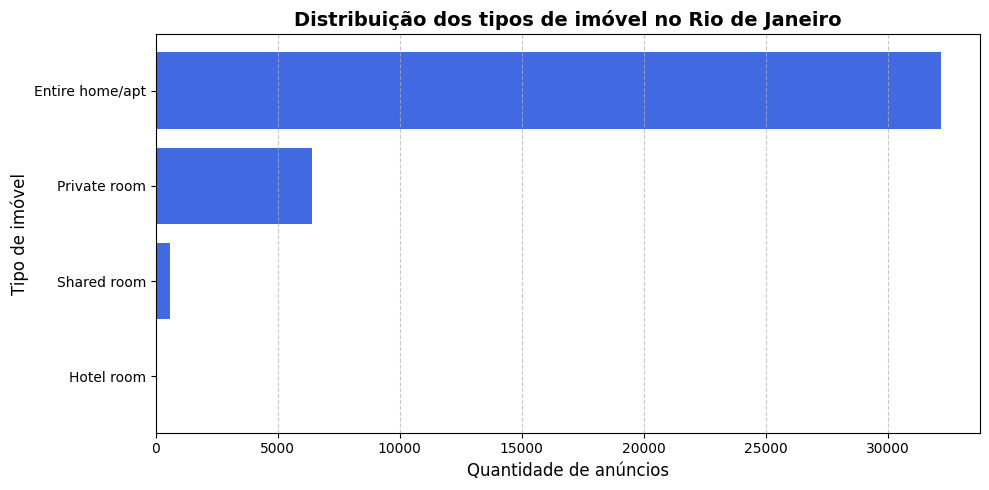

In [32]:
# Tipos de imóvel
# Célula para a Figura 4
tipo_imovel = (
    df_limpo["room_type"]
    .value_counts()
    .sort_values(ascending=True)  # Menor para o maior para a barra mais longa ficar no topo
)

plt.figure(figsize=(10, 5))
plt.barh(tipo_imovel.index, tipo_imovel.values, color="royalblue")
plt.title("Distribuição dos tipos de imóvel no Rio de Janeiro", fontsize=14, fontweight="bold")
plt.xlabel("Quantidade de anúncios", fontsize=12)
plt.ylabel("Tipo de imóvel", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

# Salvar para substituir no relatório
plt.savefig("figura4_tipo_imovel.png", dpi=300)
plt.show()

In [33]:
# Bairros mais bem avaliados
df_limpo.groupby(
    "neighbourhood_cleansed"
).agg(
    anuncios=("id", "count"),
    avaliacao=("review_scores_rating", "mean")
).query(
    "anuncios >= 50"
).sort_values(
    "avaliacao",
    ascending=False
).head(15)

,anuncios,avaliacao
neighbourhood_cleansed,,
Grajaú,58,4.915250
Paquetá,59,4.910000
Joá,54,4.906667
Tijuca,292,4.892800
Estácio,77,4.878913
Praça da Bandeira,58,4.875208
São Cristóvão,143,4.867107
Camorim,770,4.866829
Gávea,184,4.862587


In [34]:
# Oportunidade de mercado: bairros com alta avaliação e preço mediano baixo
bairro_preco["oportunidade"] = (
    bairro_preco["avaliacao"] *
    bairro_preco["preco_mediano"] /
    bairro_preco["anuncios"]
)

bairro_preco.sort_values(
    "oportunidade",
    ascending=False
).head(20)

,anuncios,preco_mediano,avaliacao,indice_custo_beneficio,oportunidade
neighbourhood_cleansed,,,,,
Joá,54,1242.770,4.906667,0.003948,112.923299
Engenho de Dentro,55,400.000,4.780000,0.011950,34.763636
Anil,52,376.670,4.720000,0.012531,34.190046
Cosme Velho,73,519.240,4.748269,0.009145,33.773854
Paquetá,59,343.000,4.910000,0.014315,28.544576
Praça da Bandeira,58,319.835,4.875208,0.015243,26.883832
Pechincha,56,308.115,4.843111,0.015719,26.647057
Jardim Guanabara,54,289.500,4.682391,0.016174,25.102820
Saúde,57,280.000,4.853333,0.017333,23.840936


In [35]:
# Gráficos

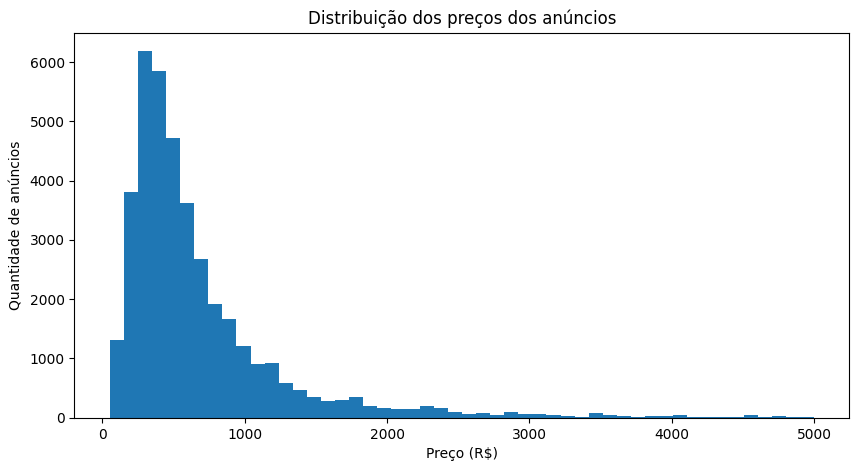

In [36]:
# Distribuição dos preços no Rio de Janeiro
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df_limpo["price"], bins=50)

plt.title("Distribuição dos preços dos anúncios")
plt.xlabel("Preço (R$)")
plt.ylabel("Quantidade de anúncios")

plt.show()

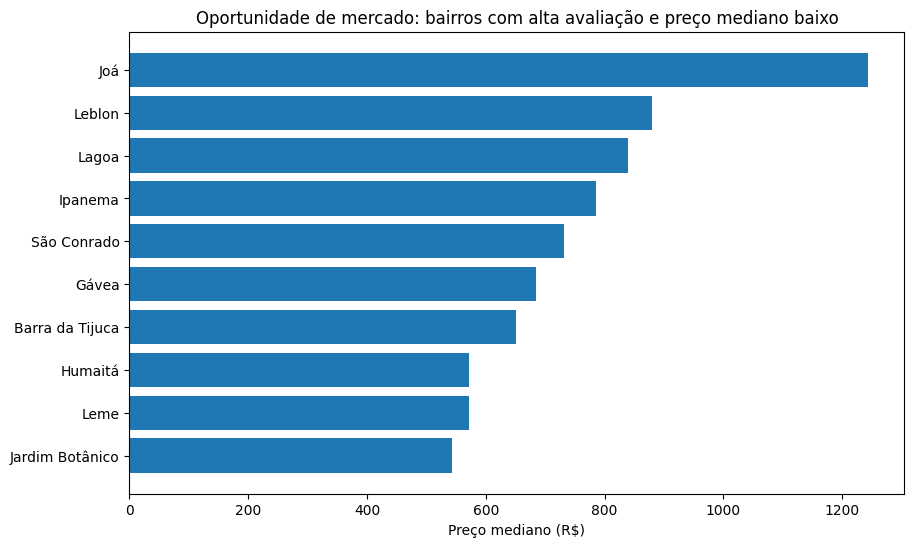

In [37]:
# Top 10 bairros mais caros
top_bairros = bairro_preco.sort_values(
    "preco_mediano",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_bairros.index,
    top_bairros["preco_mediano"]
)

plt.title("Oportunidade de mercado: bairros com alta avaliação e preço mediano baixo")
plt.xlabel("Preço mediano (R$)")

plt.gca().invert_yaxis()

plt.show()

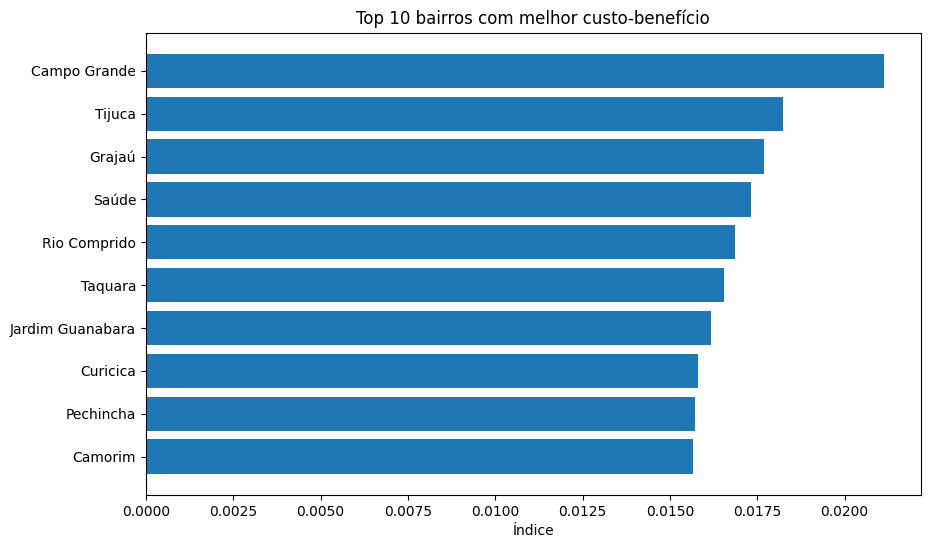

In [38]:
# Melhores bairros em custo x benefício
top_cb = bairro_preco.sort_values(
    "indice_custo_beneficio",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_cb.index,
    top_cb["indice_custo_beneficio"]
)

plt.title("Top 10 bairros com melhor custo-benefício")
plt.xlabel("Índice")

plt.gca().invert_yaxis()

plt.show()

<Figure size 800x500 with 0 Axes>

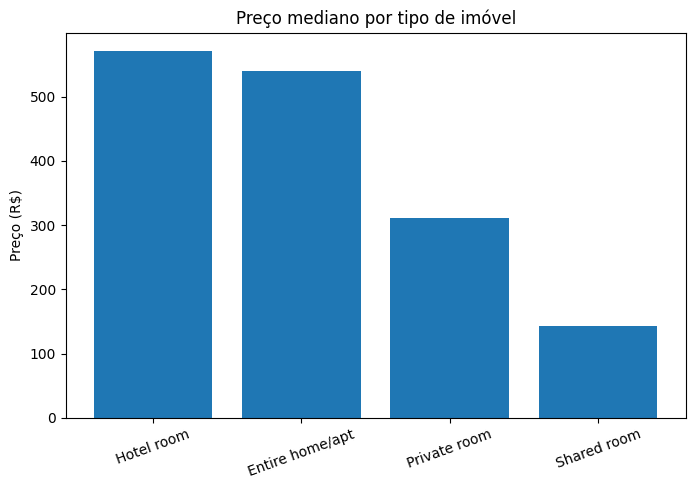

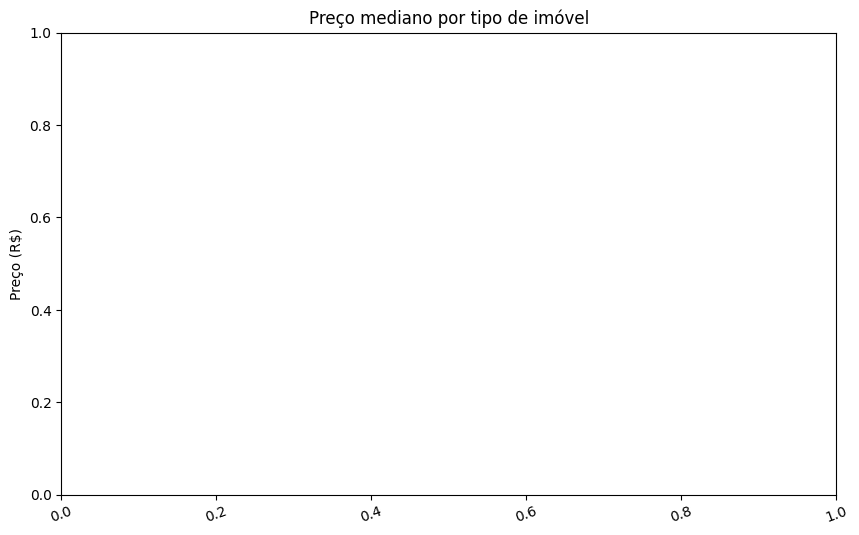

In [39]:
# Tipos de imóvel x preço mediano
plt.figure(figsize=(8,5))

# Tipos de imóvel x preço mediano
tipo_imovel = (
    df_limpo
    .groupby("room_type")
    .agg(
        anuncios=("id", "count"),
        preco_mediano=("price", "median"),
        avaliacao=("review_scores_rating", "mean")
    )
    .sort_values("preco_mediano", ascending=False)
)

plt.figure(figsize=(8,5))
plt.bar(tipo_imovel.index, tipo_imovel["preco_mediano"])
plt.title("Preço mediano por tipo de imóvel")
plt.ylabel("Preço (R$)")
plt.xticks(rotation=20)
plt.show()

plt.title("Preço mediano por tipo de imóvel")
plt.ylabel("Preço (R$)")
plt.xticks(rotation=20)

plt.show()

NameError: name 'top_avaliacao' is not defined

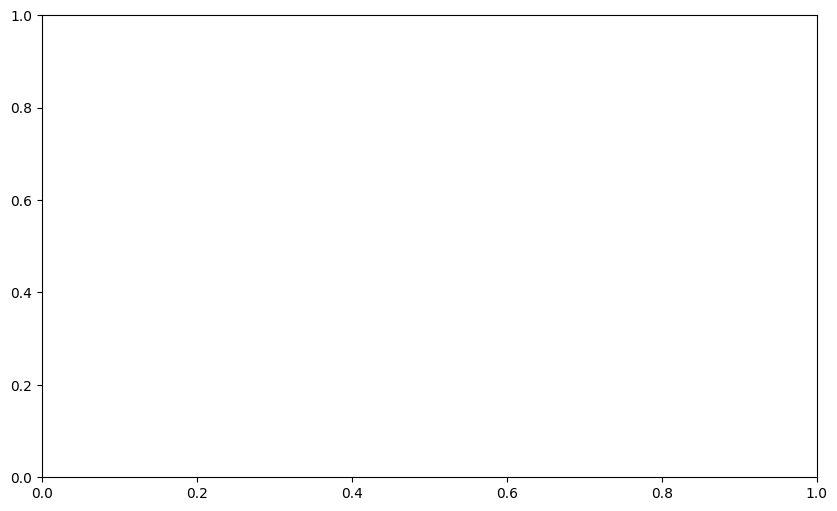

In [40]:
# Bairros mais bem avaliados
fig, ax = plt.subplots(figsize=(10,6))

barras = ax.barh(
    top_avaliacao.index,
    top_avaliacao["avaliacao"]
)

ax.set_title("Top 10 bairros mais bem avaliados")
ax.set_xlabel("Nota média")
ax.invert_yaxis()

for barra in barras:
    largura = barra.get_width()
    ax.text(
        largura + 0.002,
        barra.get_y() + barra.get_height()/2,
        f"{largura:.3f}",
        va="center"
    )

plt.show()

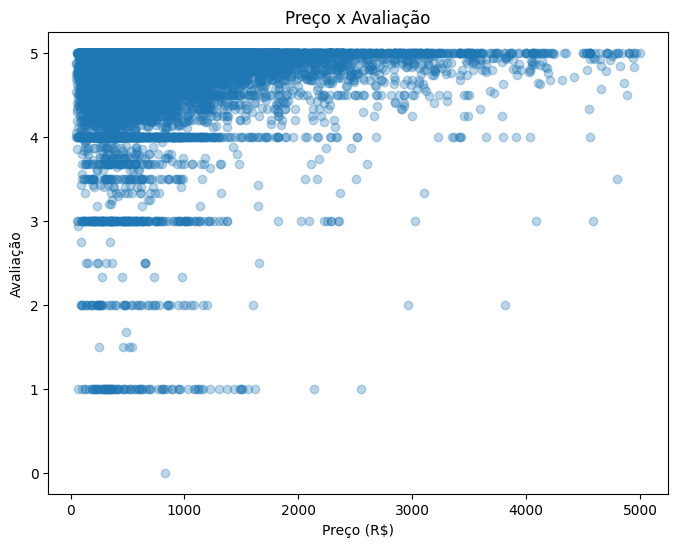

In [ ]:
# Preço x avaliação
plt.figure(figsize=(8,6))

plt.scatter(
    df_limpo["price"],
    df_limpo["review_scores_rating"],
    alpha=0.3
)

plt.title("Preço x Avaliação")
plt.xlabel("Preço (R$)")
plt.ylabel("Avaliação")

plt.show()

In [41]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', '_i2', '_i3', '_i4', 'pd', 'df', '_i5', '_i6', 'np', 'plt', '_i7', '_i8', '_i9', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', 'df_limpo', '_i16', '_16', '_i17', 'tipo_imovel', '_i18', '_i19', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_29', '_i30', 'bairro_preco', '_30', '_i31', '_31', '_i32', '_i33', '_33', '_i34', '_34', '_i35', '_i36', '_i37', 'top_bairros', '_i38', 'top_cb', '_i39', '_i40', 'fig', 'ax', '_i41'])

In [ ]:
# Calcular o índice de oportunidade para cada bairro
bairro_preco["oportunidade"] = (
    bairro_preco["avaliacao"]
    * bairro_preco["preco_mediano"]
    / bairro_preco["anuncios"]
)

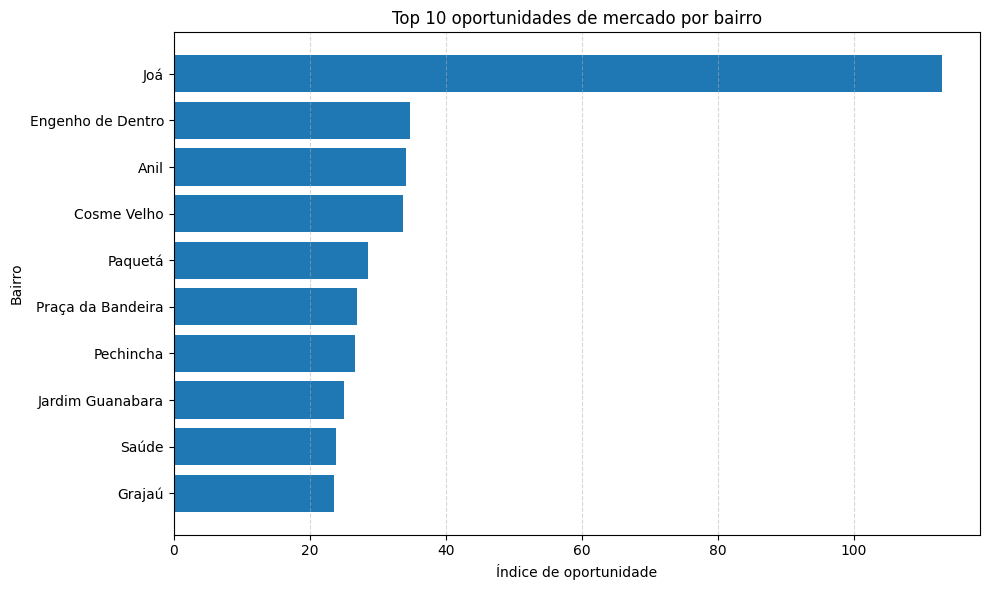

In [ ]:
# Top 10 bairros com maior índice de oportunidade
top_oportunidades = (
    bairro_preco
    .sort_values(by="oportunidade")
    .tail(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_oportunidades.index,
    top_oportunidades["oportunidade"]
)

plt.title("Top 10 oportunidades de mercado por bairro")
plt.xlabel("Índice de oportunidade")
plt.ylabel("Bairro")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()